In [1]:
%pip install git+https://github.com/illuin-tech/colpali
%pip install torch datasets pytrec_eval transformers einops natsort matplotlib
%pip install -U sentence-transformers

  Cloning https://github.com/illuin-tech/colpali to /tmp/user/25171/pip-req-build-v2hvfqpq
  Running command git clone --filter=blob:none --quiet https://github.com/illuin-tech/colpali /tmp/user/25171/pip-req-build-v2hvfqpq
  Resolved https://github.com/illuin-tech/colpali to commit 3a562fc0d78acec847f067c832ad875fcdf51d32
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Helper functions:

In [2]:
import random
import numpy as np
import torch
import pytrec_eval
from typing import Callable, List, Union
import matplotlib.pyplot as plt


seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

# helpers
def retrieve(similarity, k=10):
    top_vals, top_idx = torch.topk(similarity, k=k, dim=-1)
    retrieval_results = {}
    for q, val_row, idx_row in zip(
            range(len(top_idx)), top_vals.cpu().tolist(), top_idx.cpu().tolist()
    ):
        retrieval_results[str(q)] = {str(idx): val for (idx, val) in zip(idx_row, val_row)}
    return retrieval_results

def eval(benchmark, retrieval_results):
    evaluator = pytrec_eval.RelevanceEvaluator(benchmark, {"ndcg_cut.5"})
    scores = evaluator.evaluate(retrieval_results)
    metric_scores = [v['ndcg_cut_5'] for v in scores.values()]
    return np.array(metric_scores)

def plot_diff(scores_a, scores_b, a_label, b_label):
    diff = [a - b for a, b in zip(scores_a, scores_b)]

    plt.figure()
    plt.plot(diff)
    plt.axhline(0, linestyle="--", alpha=0.5)

    plt.xlabel("Query index")
    plt.ylabel("Δ NDCG@5")
    plt.ylim(-1, 1)
    plt.title(f"{a_label} VS {b_label}")

    # arrows + labels
    plt.text(
        0.60, 0.98,
        f"↑ better for {a_label}",
        transform=plt.gca().transAxes,
        ha="right", va="top"
    )
    plt.text(
        0.60, 0.02,
        f"↓ better for {b_label}",
        transform=plt.gca().transAxes,
        ha="right", va="bottom"
    )

    plt.show()


def plot_diffs_side_by_side(scores_a, scores_b, scores_c,
                            label_a, label_b, label_c):

    diff_ac = np.array(scores_a) - np.array(scores_c)
    diff_bc = np.array(scores_b) - np.array(scores_c)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    axes[0].plot(diff_ac)
    axes[0].axhline(0, linestyle="--", alpha=0.5)
    axes[0].set_title(f"{label_a} VS {label_c}")
    axes[0].set_xlabel("Query index")
    axes[0].set_ylabel("Δ NDCG@5")

    axes[1].plot(diff_bc)
    axes[1].axhline(0, linestyle="--", alpha=0.5)
    axes[1].set_title(f"{label_b} VS {label_c}")
    axes[1].set_xlabel("Query index")

    for ax, top_label in zip(axes, [label_a, label_b]):
        ax.set_ylim(-1, 1)
        ax.text(
            0.60, 0.98,
            f"↑ better for {top_label}",
            transform=ax.transAxes,
            ha="right", va="top"
        )
        ax.text(
            0.60, 0.02,
            f"↓ better for {label_c}",
            transform=ax.transAxes,
            ha="right", va="bottom"
        )

    fig.suptitle("Per-query NDCG@5 Differences")
    plt.tight_layout()
    plt.show()

# We'll implement our own late-interaction scoring fucntion, which will also normalize the MaxSim score by the number of query tokens in the sequence.
def score_multi_vector(
    qs: Union[torch.Tensor, List[torch.Tensor]],
    ps: Union[torch.Tensor, List[torch.Tensor]],
    batch_size: int = 32,
) -> torch.Tensor:
    scores_list: List[torch.Tensor] = []
    for i in range(0, len(qs), batch_size):
        scores_batch = []
        qs_batch = torch.nn.utils.rnn.pad_sequence(qs[i : i + batch_size], batch_first=True, padding_value=0).to(
            device
        )
        q_lens = (qs_batch.abs().sum(dim=-1) > 0).sum(dim=1).unsqueeze(1)
        for j in range(0, len(ps), batch_size):
            ps_batch = torch.nn.utils.rnn.pad_sequence(
                ps[j : j + batch_size], batch_first=True, padding_value=0
            ).to(device)
            # The ColBert maxsim operation
            breakpoint()
            scores = torch.einsum("bqh,tdh->btqd", qs_batch, ps_batch).max(dim=-1)[0].sum(dim=-1)
            # normalize by the number query tokens
            scores = scores/q_lens
            scores_batch.append(scores)
        scores_batch = torch.cat(scores_batch, dim=1)
        scores_list.append(scores_batch)

    scores = torch.cat(scores_list, dim=0)
    assert scores.shape[0] == len(qs), f"Expected {len(qs)} scores, got {scores.shape[0]}"
    return scores




# Guided Query Refinement - Tutorial

This notebook is intended to introduce the GQR method for test-time query refinement between bi-encoders of different modalities.
Check out the paper for the full details - [Guided Query Refinement: Multimodal Hybrid Retrieval with Test-Time Optimization
](https://arxiv.org/abs/2510.05038)(ICLR 26).

By the end of this tutorial, we hope to make it clear why hybrid text-image retrieval is useful and how GQR improves performance at test time. The notebook is self-contained and basic familiarity with neural retrieval is helpful yet not required.

This tutorial is organized as follows:

1. **The Task** - We begin with introducing a simple visual document retrieval task using a subset of the ViDoRe2 benchmark.

2. **The Models** - We evaluate two competitive, small-scale vision and text retrievers (≈500 to 600M parameters) on the task. We'll show that the two models perform equally well, but succeed and fail on very different queries, which suggests they provide complentary signal and motivate an hybrid approach.

3. **Hybrid Text-Image Retrieval** - We'll test two simple and straightforward strategies to combine retrievers outputs which can already significantly improve performance.

4. **Guided Query Refinement** - Finally we'll introduce the GQR algorithm. GQR refines a query embedding at test time using guidance from another retriever. We'll demonstrate that using representation-level information for aggregating retrievers outputs leads to the better use of the complementary signal and the stronger retrieval performance in this setup.


Reproducibility note:
This notebook was run on a single A100 (80GB). Older GPUs with less memory might work with reduced batch sizes.

## The Task
In visual document retrieval, the goal is to retrieve the most relevant visual document given a textual query.  
For a simple and small-scale setup, we use the *economics_reports* subset of the ViDoRe2 benchmark.

In [3]:
import datasets

documents = datasets.load_dataset("vidore/economics_reports_v2",'corpus')["test"]
queries = datasets.load_dataset("vidore/economics_reports_v2",'queries')["test"]
qrels = datasets.load_dataset("vidore/economics_reports_v2",'qrels')["test"]

We use OCR-derived document descriptions generated with [DocLing](https://docling-project.github.io/docling/), which provide a textual representation of the documents for text-based retrieval. Similar descriptions can also be produced using vision-language models.

In [4]:
from pathlib import Path
from natsort import natsorted
from collections import defaultdict

documents_texts = [p.read_text(encoding="utf-8") 
         for p in natsorted(Path("texts").glob("*.md"))]
benchmark = defaultdict(dict)

for row in qrels:
    qid = row["query-id"]
    did = row["corpus-id"]
    score = row["score"]
    benchmark[str(qid)][str(did)] = score
# We construct a benchmark object that maps each query to a dictionary of `document_id: relevance_score`.
benchmark = dict(benchmark)

To get a sense of how the data looks like:

An example Query: How do the fiscal challenges in small states compare to those in larger economies?
The original document:


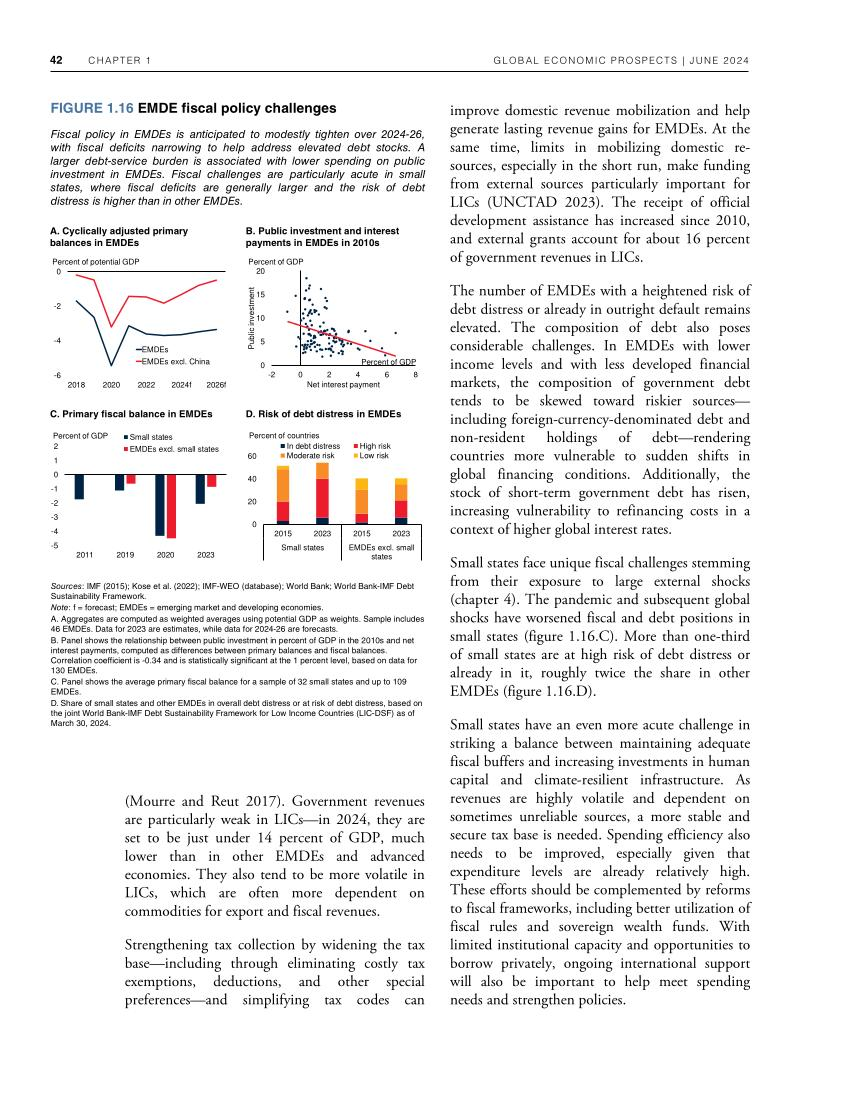

Relevance score - 2


In [5]:
from IPython.display import display

query_key, documents_to_score = list(benchmark.items())[0]
print(f"An example Query: {queries[int(query_key)]['query']}")
doc_id, score = list(documents_to_score.items())[0]
print(f"The original document:")
display(documents[int(doc_id)]['image'])
print(f"Relevance score - {score}")


The text description:

In [6]:
print({documents_texts[int(doc_id)]})

{'## FIGURE 1.16 EMDE fiscal policy challenges\n\nlo help address 4 stales, where Nscal delicils are generally larger higher than in other EMDEs.\n\nA. Cyclically adjusted primary balances in EMDEs\n\n<!-- image -->\n\n<!-- image -->\n\nB. Public Investment and Interest payments in EMDEs in 20105\n\n<!-- image -->\n\n<!-- image -->\n\n- EMDE:\n\n(Mourre and Reut 2017). Government  revenues Particularly wcak in LICs ~in 2024, to be just under 14 percent of GDP , much lower than othet EMDEs and advanced cconomics. also tend to be volatile in LICs, which arc often ore dependent on commodities for export and fiscal revenues. they They base~including   through   eliminating   costly exemptions; deductions, and Other prefcrences and simplifying codes Can special\n\nimprove domestic rcvenue mobilization and help generate limits in mobilizing   domestic cspccially in the short run, makc from external parricularly   imporranr for LICs (UNCTAD 2023). development assistance has incrcascd since 20

## The Models

For this experiment, we use **ViDoRe colSmol-500M** as the vision retriever and **Qwen3-Embedding-0.6B** as the text retriever.

For context, colSmol follows the ColBERT [late-interaction](https://arxiv.org/abs/2004.12832) paradigm (adapted to image-text retrieval in the [ColPali paper](https://arxiv.org/abs/2407.01449)). In this multi-vector setup, an image is encoded as a sequence of patch tokens and scored against query tokens using the MaxSim operator.

The text retriever uses a single-vector architecture for both documents and queries, with similarity computed via cosine similarity.

In [7]:
import torch
from colpali_engine.models import ColIdefics3, ColIdefics3Processor
from sentence_transformers import SentenceTransformer

vision_model = ColIdefics3.from_pretrained(
        "vidore/colSmol-500M",
        dtype=torch.bfloat16,
    ).to(device).eval()
vision_model_processor = ColIdefics3Processor.from_pretrained("vidore/colSmol-500M")

text_model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B",model_kwargs={"dtype": torch.bfloat16}).to(device).eval()

Loading weights:   0%|          | 0/490 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/448 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

First, we embed the documents and queries using the vision model:

In [8]:
from tqdm import tqdm
import torch.nn.functional as F

images = [row['image'] for row in documents]
queries_list = [row['query'] for row in queries]

with torch.no_grad():
    batch_vision_queries = vision_model_processor.process_queries(queries_list).to(device)
    vision_queries_embeddings = vision_model(**batch_vision_queries)

    # set up batching
    vision_documents_embeddings = []
    batch_size = 32 # adjust this based on your hardware
    for batch_start in tqdm(range(0, len(images), batch_size)):
        batch = images[batch_start: batch_start + batch_size]
        batch_images = vision_model_processor.process_images(batch).to(device)
        vision_documents_embeddings.append(vision_model(**batch_images))
    # Pad the sequence dimension to the max, and concat along the batch dimension
    max_seq_dim = max([t.shape[1] for t in vision_documents_embeddings])
    padded_image_embeddings = []
    for t in vision_documents_embeddings:
        padded_image_embeddings.append(F.pad(t,(0,0,0,max_seq_dim-t.shape[1])))
    vision_documents_embeddings = torch.concat(padded_image_embeddings,dim=0,)

100%|██████████| 15/15 [02:35<00:00, 10.39s/it]


Then using the text model:

In [9]:
text_query_embeddings = text_model.encode(queries_list, prompt_name="query")
text_documents_embeddings = text_model.encode(documents_texts)

Now we evaluate retrieval performance.

For simplicity, we compute full query–document similarity matrices for each model. (In real settings, this is not feasible, and retrieval would rely on an indexing backend with efficient ANN or late-interaction search.)

In [10]:
query_image_similarity = score_multi_vector(vision_queries_embeddings, vision_documents_embeddings)
query_text_similarity  = text_model.similarity(text_query_embeddings, text_documents_embeddings).to(device)

image_retrieval = retrieve(query_image_similarity)
text_retrieval = retrieve(query_text_similarity)

vision_scores = eval(benchmark,image_retrieval)
text_scores = eval(benchmark,text_retrieval)

print(f"Vision mean NDCG: {vision_scores.mean().item():.4f}")
print(f"Text mean NDCG: {text_scores.mean().item():.4f}")

Vision mean NDCG: 0.3612
Text mean NDCG: 0.4155


At first glance, the text retriever performs better on average.

Yet it’s worth looking more closely at per-query behavior. We start by measuring the win rate of the different encoders across queries:

In [11]:
text_win_rate = np.mean(text_scores > vision_scores)
vision_win_rate = np.mean(text_scores > vision_scores)
tie_rate = np.mean(text_scores == vision_scores)

print(f"Text retriever win rate over vision: {text_win_rate:.4f}")
print(f"Vision retriever win rate over text: {vision_win_rate:.4f}")
print(f"Text-Vision Tie rate: {tie_rate:.4f}")

Text retriever win rate over vision: 0.4828
Vision retriever win rate over text: 0.4828
Text-Vision Tie rate: 0.1509


**Maybe surprisingly, the win rate across queries is the same.** This suggests that the text retriever does not dominate the vision retriever, but that the two models succeed and fail on different subsets of queries. (An emprical observation that is also more broadly supported by [recent work](https://arxiv.org/abs/2602.17687v1))

We can further illustrate this by plotting the NDCG@5 difference as a function of query ID. Positive values indicate that the vision retriever outperforms the text retriever, while negative values indicate the opposite.

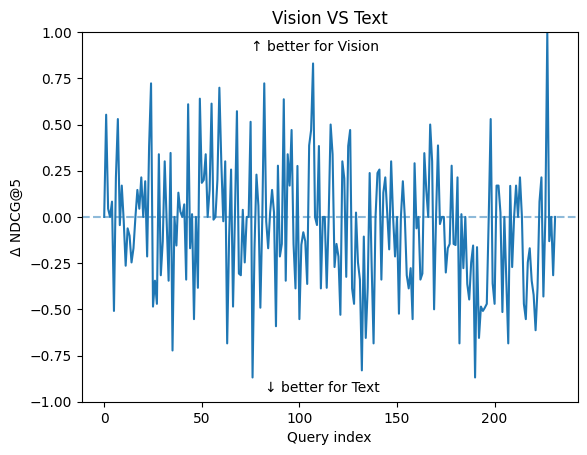

In [12]:
plot_diff(vision_scores, text_scores, "Vision", "Text")

The plot clearly shows that performance varies substantially across queries, and that neither retriever consistently outperforms the other.

With this information in mind, which retriever would you choose for your retrieval pipeline?

This basic analysis suggest that the signal from the two retrievers is complementary, and naturally motivates an hybrid approach! **Can we leverage the complementary signal of the retrievers for better downstream performance?**

## Hybrid Text-Image Retrieval

We begin by investigating two simple hybrid approaches:

1. **Average Rank Fusion**  
   Each retriever produces a ranking over documents. The fused ranking is obtained by averaging the rank assigned by each retriever.

   $$
   r_{\text{fused}}(d)
   =
   \frac{1}{M}
   \sum_{m=1}^{M}
   r_m(d)
   $$

   where \(r_m(d)\) is the rank of document \(d\) under retriever \(m\), and lower values indicate better ranks.

2. **Average Score Fusion**  
   Each retriever produces similarity scores, which are first normalized with a softmax and then averaged.

   $$
   s_{\text{fused}}(d)
   =
   \frac{1}{M}
   \sum_{m=1}^{M}
   \mathrm{softmax}(s_m)_d
   $$

   where \(s_m\) is the score vector produced by retriever \(m\).

(See the paper for more details.)

In [13]:
# Return a new ranking by averaging the rank of each document
# If a document is retrieved by only one retriever, we treat its rank for the other as k 
def average_ranking_fusion(rankings_a, rankings_b):
    fused_rankings = {}
    for query_id, ranking_a in rankings_a.items():
        ranking_b = rankings_b.get(query_id, {})
        # Build doc -> rank maps
        ranks_a = {doc_id: rank for rank, doc_id in enumerate(ranking_a)}
        ranks_b = {doc_id: rank for rank, doc_id in enumerate(ranking_b)}

        k = len(ranking_a)
        all_doc_ids = set(ranking_a) | set(ranking_b)
        # Sort documents by average rank
        sorted_docs = sorted(
            all_doc_ids,
            key=lambda doc_id: (
                ranks_a.get(doc_id, k) +
                ranks_b.get(doc_id, k)
            ) / 2,
        )

        # Store average score, ordered by average rank
        fused_rankings[query_id] = {
            doc_id: 1-(i/k)
            for i,doc_id in enumerate(sorted_docs)
        }

    return fused_rankings

# Return a new ranking by averaging the rank of each document
# If a document is retrieved by only one retriever, we treat its rank for the other ask k+1
def sim_score_fusion(rankings_a, rankings_b):
    fused = {}
    for query_id in rankings_a:
        scores_a = rankings_a.get(query_id, {})
        scores_b = rankings_b.get(query_id, {})

        doc_ids_a, raw_a = zip(*scores_a.items())
        doc_ids_b, raw_b = zip(*scores_b.items())

        probs_a = dict(zip(
            doc_ids_a,
            torch.softmax(torch.tensor(raw_a), dim=0).tolist()
        ))

        probs_b = dict(zip(
            doc_ids_b,
            torch.softmax(torch.tensor(raw_b), dim=0).tolist()
        ))

        all_doc_ids = set(scores_a) | set(scores_b)

        fused_scores = {
            doc_id: (probs_a.get(doc_id, 0.0) + probs_b.get(doc_id, 0.0))/2
            for doc_id in all_doc_ids
        }

        fused[query_id] = dict(
            sorted(fused_scores.items(), key=lambda kv: kv[1], reverse=True)
        )

    return fused


Let’s compare the two approaches:

In [14]:
avg_rank = average_ranking_fusion(text_retrieval, image_retrieval)
avg_rank_scores = eval(benchmark, avg_rank)

print(f"Avg-Rank mean NDCG: {avg_rank_scores.mean():.4f}")
print("-"*100)
rank_vs_text_win = np.mean(avg_rank_scores > text_scores)
rank_vs_text_tie = np.mean(avg_rank_scores == text_scores)
rank_vs_text_loss = np.mean(avg_rank_scores < text_scores)

rank_vs_vision_win = np.mean(avg_rank_scores > vision_scores)
rank_vs_vision_tie = np.mean(avg_rank_scores == vision_scores)
rank_vs_vision_loss = np.mean(avg_rank_scores < vision_scores)

print(f"Avg-Rank > Text win rate: {rank_vs_text_win:.4f}")
print(f"Avg-Rank == Text (tie rate): {rank_vs_text_tie:.4f}")
print(f"Avg-Rank < Text loss rate: {rank_vs_text_loss:.4f}")
print("-"*100)
print(f"Avg-Rank > Vision win rate: {rank_vs_vision_win:.4f}")
print(f"Avg-Rank == Vision (tie rate): {rank_vs_vision_tie:.4f}")
print(f"Avg-Rank < Vision loss rate: {rank_vs_vision_loss:.4f}")

print("-"*100)
print("-"*100)

avg_score = sim_score_fusion(text_retrieval, image_retrieval)
avg_score_scores = eval(benchmark, avg_score)

print(f"Avg-Score mean NDCG: {avg_score_scores.mean():.4f}")
print("-"*100)
score_vs_text_win = np.mean(avg_score_scores > text_scores)
score_vs_text_tie = np.mean(avg_score_scores == text_scores)
score_vs_text_loss = np.mean(avg_score_scores < text_scores)

score_vs_vision_win = np.mean(avg_score_scores > vision_scores)
score_vs_vision_tie = np.mean(avg_score_scores == vision_scores)
score_vs_vision_loss = np.mean(avg_score_scores < vision_scores)

print(f"Avg-Score > Text win rate: {score_vs_text_win:.4f}")
print(f"Avg-Score == Text (tie rate): {score_vs_text_tie:.4f}")
print(f"Avg-Score < Text loss rate: {score_vs_text_loss:.4f}")
print("-"*100)
print(f"Avg-Score > Vision win rate: {score_vs_vision_win:.4f}")
print(f"Avg-Score == Vision (tie rate): {score_vs_vision_tie:.4f}")
print(f"Avg-Score < Vision loss rate: {score_vs_vision_loss:.4f}")


Avg-Rank mean NDCG: 0.4310
----------------------------------------------------------------------------------------------------
Avg-Rank > Text win rate: 0.4181
Avg-Rank == Text (tie rate): 0.2112
Avg-Rank < Text loss rate: 0.3707
----------------------------------------------------------------------------------------------------
Avg-Rank > Vision win rate: 0.4914
Avg-Rank == Vision (tie rate): 0.2155
Avg-Rank < Vision loss rate: 0.2931
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Avg-Score mean NDCG: 0.4306
----------------------------------------------------------------------------------------------------
Avg-Score > Text win rate: 0.3750
Avg-Score == Text (tie rate): 0.3190
Avg-Score < Text loss rate: 0.3060
----------------------------------------------------------------------------------------------------
Avg-Score > Vision wi

Both methods improve retrieval performance and perform similarly overall. They achieve higher average performance than either individual model (43 NDCG@5 vs. 41/36) on average and are also better when measuring queries win-rates.

We can also plot per-query performance of the hybrid methods alongside the individual models:

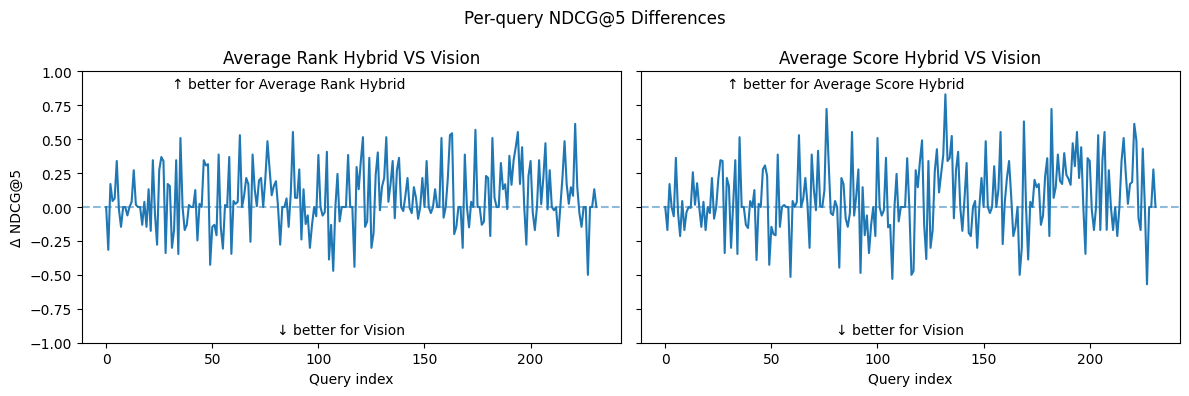

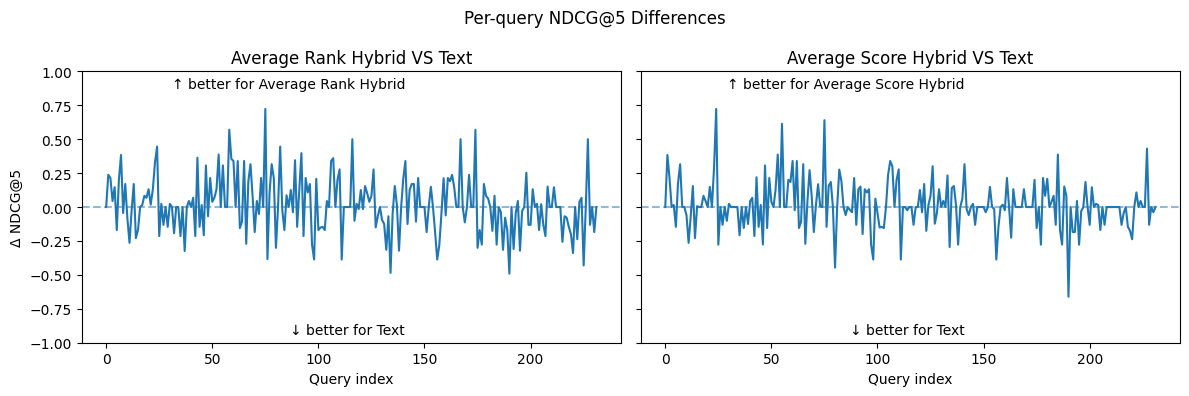

In [15]:
plot_diffs_side_by_side(avg_rank_scores,avg_score_scores,vision_scores,"Average Rank Hybrid","Average Score Hybrid","Vision")
plot_diffs_side_by_side(avg_rank_scores,avg_score_scores,text_scores,"Average Rank Hybrid","Average Score Hybrid","Text")

The y-axis trends more positive than negative across all subplots, indicating that the hybrid methods generally outperform the individual models.

So far, simple hybrid strategies already improve performance. **Can we do better?**

# Guided Query Refinement

The previous hybrid methods combine ranking- and score-level signals from the two retrievers. However, the richest signal lies in the representations themselves. Instead of combining outputs after retrieval, can we directly leverage the embedding space for more effective aggregation at test time?

To address this, we introduce **[Guided Query Refinement (GQR)](https://arxiv.org/abs/2510.05038)**. The key idea is to optimize the query embedding of a primary retriever using the complementary signal provided by another retriever’s scores. Rather than fusing rankings or scores, we refine the representation itself so that it better aligns with cross-modal evidence.

We refer the reader to the paper for full algorithmic details and a deeper discussion of the motivation behind this approach.

The following diagram illustrates the method:

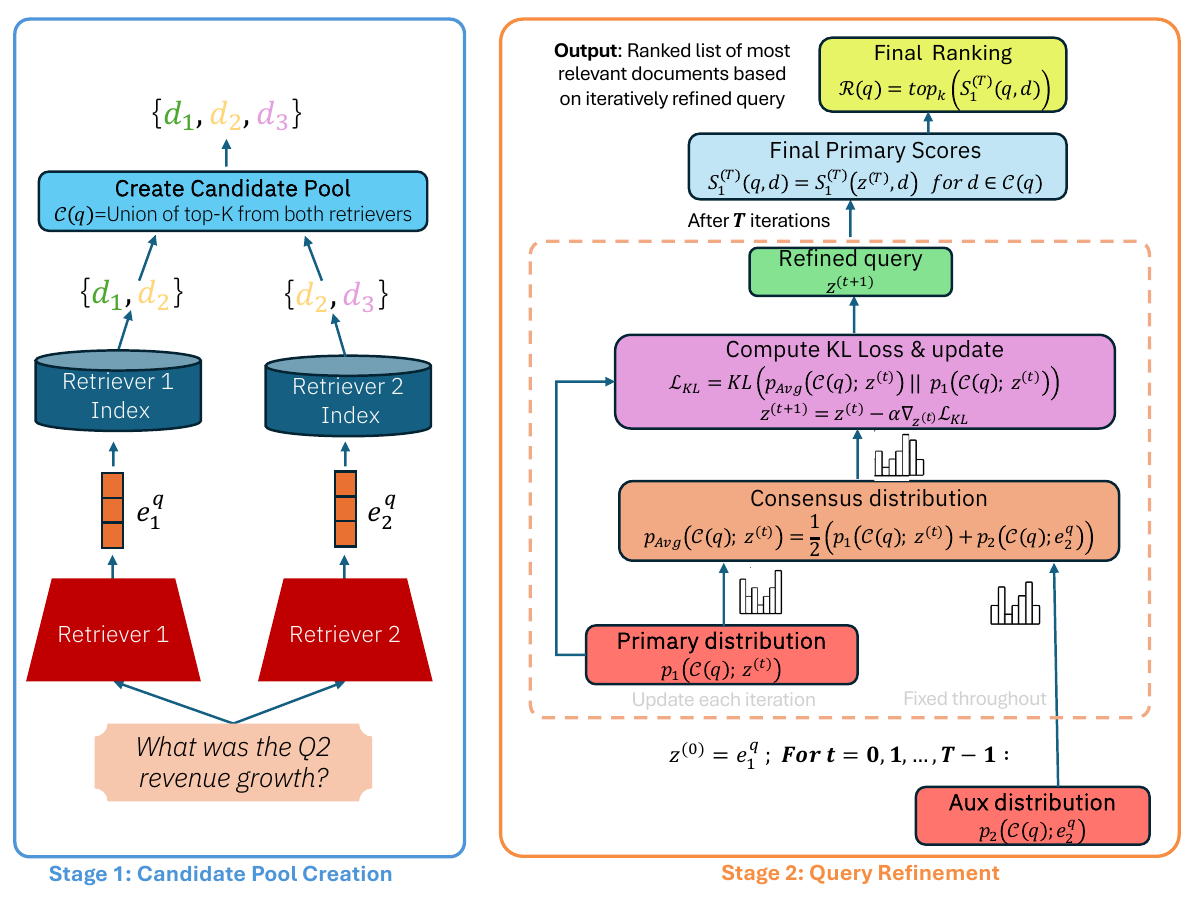

In [16]:
from PIL import Image
display(Image.open("GQR_diag_ret_1_2.png"))

In [17]:
def guided_query_refinement(
    query_emb_main,
    doc_emb_main,
    sim_main,
    sim_feedback,
    sim_func,
    lr,
    n_steps,
    k=10,
):
    n_queries = query_emb_main.shape[0]
    qs = [query_emb_main[i : i + 1].clone().detach().requires_grad_(True) for i in range(n_queries)]
    
    _, top_idx1 = torch.topk(sim_main, k=k, dim=-1)
    _, top_idx2 = torch.topk(sim_feedback, k=k, dim=-1)

    for i in range(n_queries):
        opt = torch.optim.Adam([qs[i]], lr=lr)
        idx1 = top_idx1[i]
        idx2 = top_idx2[i]
        u = torch.unique(torch.cat([idx1, idx2], dim=0))
        docs_u = doc_emb_main.index_select(0, u)

        d1 = sim_main[i].index_select(0, u)
        d2 = sim_feedback[i].index_select(0, u)
        mixture_d = torch.softmax(((d1 + d2) / 2), dim=-1).detach()

        for _ in range(n_steps):
            pred_scores = sim_func(qs[i], docs_u).to(device).squeeze(0)
            loss = F.kl_div(
                torch.log_softmax(pred_scores, dim=-1),
                mixture_d,
                reduction="batchmean"
            )

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

    refined_queries = torch.cat([q.detach() for q in qs], dim=0)
    return refined_queries

The GQR method relies on two main hyperparameters: the learning rate (`lr`) and the number of gradient descent steps (`n_steps`).

Larger learning rates typically require fewer steps, while smaller learning rates allow for more refinement steps.

Here, we evaluate a few configurations chosen based on the analysis in the paper.

In [18]:
configs = [
    {"lr": 5e-3, "n_steps": 15},
    {"lr": 1e-3, "n_steps": 20},
    {"lr": 5e-4, "n_steps": 30},
]

for cfg in configs:
    print(f"Running GQR | lr={cfg['lr']} | n_steps={cfg['n_steps']}")
    print("-" * 100)

    refined_queries_embeddings = guided_query_refinement(
        query_emb_main=vision_queries_embeddings,
        doc_emb_main=vision_documents_embeddings,
        sim_main=query_image_similarity,
        sim_feedback=query_text_similarity,
        sim_func=score_multi_vector,
        lr=cfg["lr"],
        n_steps=cfg["n_steps"],
    )

    sim_gqr = score_multi_vector(
        refined_queries_embeddings,
        vision_documents_embeddings,
    )

    gqr_retrieval = retrieve(sim_gqr)
    gqr_scores = eval(benchmark, gqr_retrieval)

    print(f"GQR mean NDCG: {gqr_scores.mean():.4f}")

    vs_text = {
        "win": np.mean(gqr_scores > text_scores),
        "tie": np.mean(gqr_scores == text_scores),
        "loss": np.mean(gqr_scores < text_scores),
    }

    vs_vision = {
        "win": np.mean(gqr_scores > vision_scores),
        "tie": np.mean(gqr_scores == vision_scores),
        "loss": np.mean(gqr_scores < vision_scores),
    }

    print(f"GQR > Text    : {vs_text['win']:.4f}")
    print(f"GQR == Text   : {vs_text['tie']:.4f}")
    print(f"GQR < Text    : {vs_text['loss']:.4f}")
    print("-" * 100)
    print(f"GQR > Vision  : {vs_vision['win']:.4f}")
    print(f"GQR == Vision : {vs_vision['tie']:.4f}")
    print(f"GQR < Vision  : {vs_vision['loss']:.4f}")
    print("=" * 100)

Running GQR | lr=0.005 | n_steps=15
----------------------------------------------------------------------------------------------------
GQR mean NDCG: 0.4546
GQR > Text    : 0.4095
GQR == Text   : 0.3922
GQR < Text    : 0.1983
----------------------------------------------------------------------------------------------------
GQR > Vision  : 0.5259
GQR == Vision : 0.1509
GQR < Vision  : 0.3233
Running GQR | lr=0.001 | n_steps=20
----------------------------------------------------------------------------------------------------
GQR mean NDCG: 0.4450
GQR > Text    : 0.4612
GQR == Text   : 0.2371
GQR < Text    : 0.3017
----------------------------------------------------------------------------------------------------
GQR > Vision  : 0.5129
GQR == Vision : 0.1897
GQR < Vision  : 0.2974
Running GQR | lr=0.0005 | n_steps=30
----------------------------------------------------------------------------------------------------
GQR mean NDCG: 0.4442
GQR > Text    : 0.4526
GQR == Text   : 0.211

Across configurations, GQR consistently improves the visual retriever, increasing average performance from about **36 NDCG@5** to **44–45 NDCG@5** (≈ +9 points).

Compared to the text retriever, GQR is competitive across queries: it wins on roughly 41–46% of queries, ties on a large fraction, and loses on only about 20–30%.

Compared to the original vision retriever, the improvement is even clearer, with GQR winning on roughly half of the queries while keeping loss rates relatively low.

We can further visualize the per-query changes in NDCG@5:

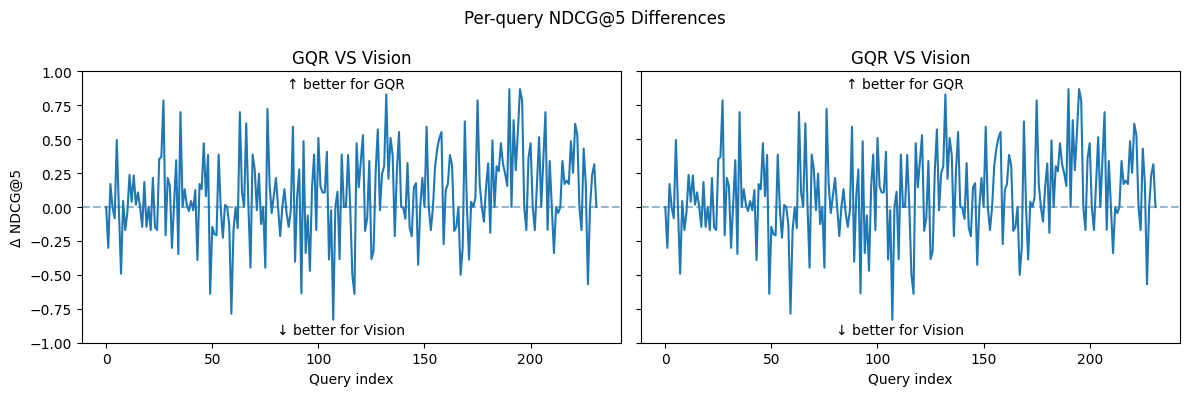

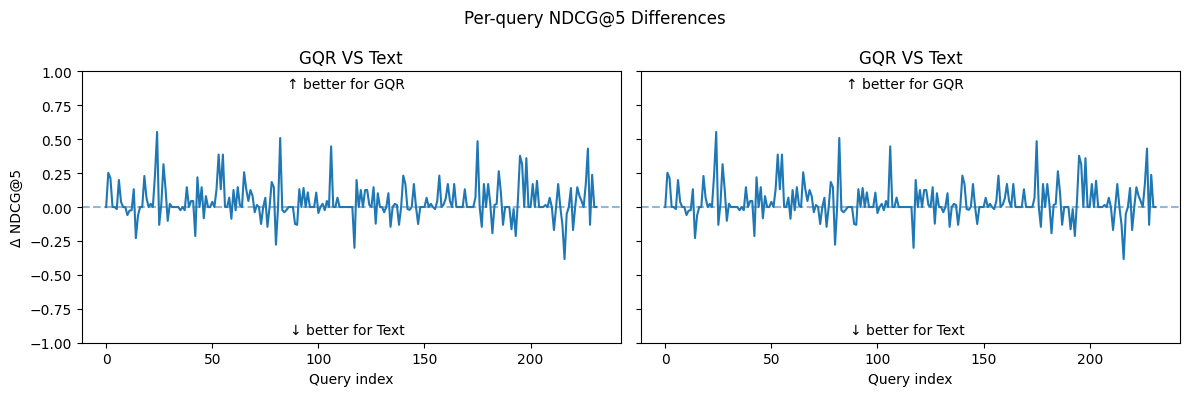

In [19]:
cfg = configs[0]
lr, n_steps = cfg["lr"], cfg["n_steps"]

refined_q = guided_query_refinement(
    query_emb_main=vision_queries_embeddings,
    doc_emb_main=vision_documents_embeddings,
    sim_main=query_image_similarity,
    sim_feedback=query_text_similarity,
    sim_func=score_multi_vector,
    lr=lr,
    n_steps=n_steps,
)

sim_gqr = score_multi_vector(refined_q, vision_documents_embeddings)
gqr_retrieval = retrieve(sim_gqr)
gqr_scores = eval(benchmark, gqr_retrieval)
plot_diffs_side_by_side(gqr_scores,gqr_scores,vision_scores,"GQR","GQR","Vision")
plot_diffs_side_by_side(gqr_scores,gqr_scores,text_scores,"GQR","GQR","Text")

We hope you enjoyed this tutorial and found vision–text hybrid retrieval and GQR interesting and useful.

We believe there are many exciting directions and open research questions for further improving multimodal retrieval. We would greatly appreciate any suggestions or feedback, feel free to reach out with comments, ideas, or questions!
